# V_loop — Voltage-loop transfer functions

Small-signal / AC transfer function of every **marked stage** of the voltage control loop on
page 2 of `stepbystep/simple loops.pdf` (KiCad sheet `V_loop.kicad_sch`).

Every component value is a **variable** in the *Parameters* cell — edit and re-run to explore.

---
### The loop (verified from the KiCad netlist)
```
  V_set ->(+)|                                    +36V
           |  U1  |->D1->  Q1 (g_m1=1/R4) -> Q2 (beta) --,  i_c2
  V_fb --R1-(-)|   error        driver          PNP Darl. |
           ^   amp/comp                                   v
           |                                        [ R5+C2 ] || [ R6 load ]  = Z_out
           |                                                   |  V_out
           |          U2 difference amp (R7,R9,R10,R11)        |
           '----------------  V_fb = H4 * V_out  <-------------'
```

| Box | Stage | Transfer function | Units |
|----|-------|-------------------|-------|
| U1 | Error amp / **compensator** | $H_1=-Z_f/R_1$,  $Z_f=(R_2+\tfrac{1}{sC_1})\parallel\tfrac{1}{sC_3}$ | V/V |
| Q1,Q2,R3,R4,D1 | **Driver + pass** | $H_2=i_{c2}/V_e=\beta_2\,g_{m1}\,\tfrac{R_3}{R_3+r_d}$ | A/V |
| R5,C2,R6 | **Output network** | $H_3=V_{out}/i_{c2}=Z_{out}$ | $\Omega$ |
| U2 | **Feedback** sense | $H_4=V_{fb}/V_{out}=(1+\tfrac{R_9}{R_{11}})\tfrac{R_7}{R_7+R_{10}}$ | V/V |

**Loop gain** $T(s)=H_1H_2H_3H_4$ (U1 is inverting → that 180° closes the *negative* feedback;
below we plot the frequency-shaping magnitude/phase and read phase margin as
$\mathrm{PM}=180^\circ+\angle T(j\omega_c)$ at the $|T|=1$ crossover).

## 1 · Parameters — edit these

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#  COMPONENT VALUES
#  compensator R2/C1/C3 = OPTIMIZED for the REAL device
#  dynamics (TIP125 beta rolloff + op-amp GBW), across load
#  types AND beta spread -- see sections 9/10.
#  schematic first-guess values in trailing comments.
# ============================================================
# --- Stage 1: error amplifier / compensator (U1) -----------
R1  = 10e3     # input resistor  V_fb -> U1(-)                 [ohm]
R2  = 18e3     # zero-setting R in feedback (series with C1)   [ohm]   (was 10k)
C1  = 47e-9    # feedback capacitor (series with R2)           [F]     (was 1n)
C3  = 22e-12   # HF feedback cap (parallel branch); 0 = DNP    [F]     (was 0)
GBW = 5.7e6    # op-amp gain-bandwidth product (U1 and U2)     [Hz]
# (op-amp slew rate 2.8 V/us -- large-signal only, not in the AC model)

# --- Stage 2: driver + pass transistor (Q1,R3,R4,D1,Q2) ----
R3      = 1e3    # Q1 base pull-up (bias; AC divider with rd_D1)   [ohm]
R4      = 150.0  # Q1 emitter degeneration -> g_m1 = 1/(R4+re1)    [ohm]
Q2_beta = 2000.0 # TIP125 hfe, TYP from datasheet Fig.7/9 @ 3A     [-]
                 #   (datasheet min 1000; section 10 sweeps 500..4000)
fbeta1  = 60e3   # TIP125 hfe 1st pole  (Fig.7 fit, PNP @ 3A)      [Hz]
fbeta2  = 300e3  # TIP125 hfe 2nd pole  (Fig.7 fit)                [Hz]
re1     = 0.0    # Q1 small-signal emitter r = VT/Ic1 (0 = ideal)  [ohm]
rd_D1   = 26.0   # D1 dynamic resistance ~VT/1mA bias              [ohm]
fp_pass = 1e9    # optional EXTRA pass pole (Hz); large => disabled [Hz]

# --- Stage 3: output network (R5, C2, load R6) -------------
R5 = 0.2       # ESR of output capacitor C2                    [ohm]
C2 = 10e-6     # output capacitor                              [F]
# load R6 = R_load || ( R_esrL + 1/(s*C_load) )   ('100 || 1uF +1')
R_load = 100.0 # load resistance                               [ohm]
C_load = 1e-6  # load capacitance                              [F]
R_esrL = 1.0   # load-cap ESR                                  [ohm]

# --- Stage 4: feedback sense amplifier (U2) ----------------
R7  = 2.2e3    # U2(+) -> GND                                  [ohm]
R9  = 2.2e3    # U2 feedback  out -> U2(-)                     [ohm]
R10 = 33e3     # V_out -> U2(+)                                [ohm]
R11 = 33e3     # U2(-) -> GND                                  [ohm]

# --- frequency axis ----------------------------------------
f = np.logspace(0, 7, 6000)     # 1 Hz .. 10 MHz
w = 2*np.pi*f
s = 1j*w
print('parameters loaded')

parameters loaded


## 2 · Stage 1 — Error amplifier / compensator (U1)

Inverting op-amp: input resistor $R_1$ from the feedback voltage $V_{fb}$, feedback impedance
$Z_f$ from output to the (−) input; the setpoint $V_{set}$ enters the (+) input.

$$Z_f(s)=\Big(R_2+\frac{1}{sC_1}\Big)\ \Big\|\ \frac{1}{sC_3}
=\frac{1+sR_2C_1}{s\,(C_1+C_3)\,\big(1+sR_2\,\frac{C_1C_3}{C_1+C_3}\big)}
\qquad H_1(s)=\frac{V_e}{V_{err}}=-\frac{Z_f(s)}{R_1}$$

A **type-II** compensator: integrator $\frac{1}{sR_1(C_1+C_3)}$, a zero at
$f_z=\frac{1}{2\pi R_2C_1}$ and an HF pole at $f_p=\frac{C_1+C_3}{2\pi R_2C_1C_3}$.
With the optimized values ($R_2=33\,$k, $C_1=10\,$n, $C_3=47\,$p):
$f_z\approx480\,$Hz, mid-band gain $R_2/R_1=3.3$ (10.4 dB), $f_p\approx103\,$kHz.
(Setting $R_2=0,\ C_3=0$ recovers the original pure integrator
$H_1=-\frac{1}{sR_1C_1}$.)

In [13]:
# feedback impedance (admittance form => C3=0 handled cleanly)
Z_branch = R2 + 1.0/(s*C1)          # R2 in series with C1
Y_f      = 1.0/Z_branch + s*C3      # add C3 as parallel admittance
Zf       = 1.0/Y_f

H1 = Zf/R1                          # |compensator gain| (U1 is inverting: physical = -H1)

## 3 · Stage 2 — Driver + pass transistor (Q1, R3, R4, D1, Q2)

$U1$'s output $V_e$ drives $Q1$'s base through $D1$ ($R_3$ pulls the base to $+3.3\,$V, bias only).
$Q1$ is a common-emitter stage with emitter degeneration $R_4$, transconductance
$g_{m1}=1/(R_4+r_{e1})$. Its collector current is the base current of the PNP Darlington $Q2$
(emitter at $+36\,$V, **collector = output**), which multiplies it by $\beta_2$. Net transconductance:

$$H_2(s)=\frac{i_{c2}}{V_e}=\underbrace{\frac{R_3}{R_3+r_d}}_{\text{D1 divider}=1}
\cdot\underbrace{\frac{1}{R_4+r_{e1}}}_{g_{m1}}\cdot\underbrace{\beta_2}_{Q2}
\quad[\mathrm{A/V}]\;=\;\frac{\beta_2}{R_4}=6.67\ \mathrm{A/V}$$

Flat with frequency in this simplified model (Darlington $f_T$/Miller ignored); set `fp_pass`
to add a single pass-stage pole.

In [14]:
gm1     = 1.0/(R4 + re1)            # Q1 transconductance with degeneration
diode   = R3/(R3 + rd_D1)           # D1/R3 divider  (=1 when rd_D1=0)
Gm_dc   = Q2_beta * gm1 * diode     # transconductance V_e -> i_c2   [A/V]
H2      = Gm_dc / (1.0 + s/(2*np.pi*fp_pass))   # optional bandwidth pole

## 4 · Stage 3 — Output network (R5, C2, load R6)

$Q2$'s collector is a current source $i_{c2}$ (high output impedance) driving the parallel
combination of the output capacitor $C_2$ (ESR $R_5$) and the load $R_6$. The load is modelled as
$R_{load}\parallel(R_{esrL}+\tfrac{1}{sC_{load}})$ (your *'100 Ω ∥ 1 µF + 1 Ω'*):

$$Z_{out}(s)=\Big(R_5+\frac{1}{sC_2}\Big)\ \Big\|\ \Big[R_{load}\ \big\|\ \big(R_{esrL}+\tfrac{1}{sC_{load}}\big)\Big],
\qquad H_3(s)=\frac{V_{out}}{i_{c2}}=Z_{out}(s)$$

Key features: load pole $\approx\frac{1}{2\pi R_{load}C_{load}}\!\approx\!1.6\,$kHz,
$C_2$-ESR zero $\frac{1}{2\pi R_5C_2}\!\approx\!80\,$kHz, load-ESR zero
$\frac{1}{2\pi R_{esrL}C_{load}}\!\approx\!159\,$kHz.

In [15]:
Z_cap  = R5 + 1.0/(s*C2)                              # output cap + its ESR
Z_load = 1.0/(1.0/R_load + 1.0/(R_esrL + 1.0/(s*C_load)))  # 100 || (1 + 1/sCload)
Z_out  = 1.0/(1.0/Z_cap + 1.0/Z_load)                # cap || load
H3     = Z_out

## 5 · Stage 4 — Feedback sense amplifier (U2)

$U2$ is a difference amplifier: $V_{out}$ enters the (+) input through $R_{10}$ (with $R_7$ to GND),
$R_{11}$ ties the (−) input to GND and $R_9$ is the feedback. Purely resistive → **flat gain**:

$$H_4=\frac{V_{fb}}{V_{out}}=\Big(1+\frac{R_9}{R_{11}}\Big)\frac{R_7}{R_7+R_{10}}
\;\xrightarrow[\;R_7/R_{10}=R_9/R_{11}\;]{}\;\frac{R_9}{R_{11}}=\frac{2.2\text{k}}{33\text{k}}=\frac{1}{15}$$

So the loop regulates $V_{out}\approx 15\,V_{set}$.

In [16]:
H4 = (1.0 + R9/R11) * (R7/(R7 + R10))    # flat feedback gain V_fb/V_out
print('H4 = %.5f   (V_out = %.2f x V_set)' % (H4, 1.0/H4))

H4 = 0.06667   (V_out = 15.00 x V_set)


## 6 · Bode plots of the four stages

Magnitude and phase of each stage (phase = frequency-shaping part; $U1$ and the loop are
inverting, i.e. an extra fixed 180° that realises the negative feedback).

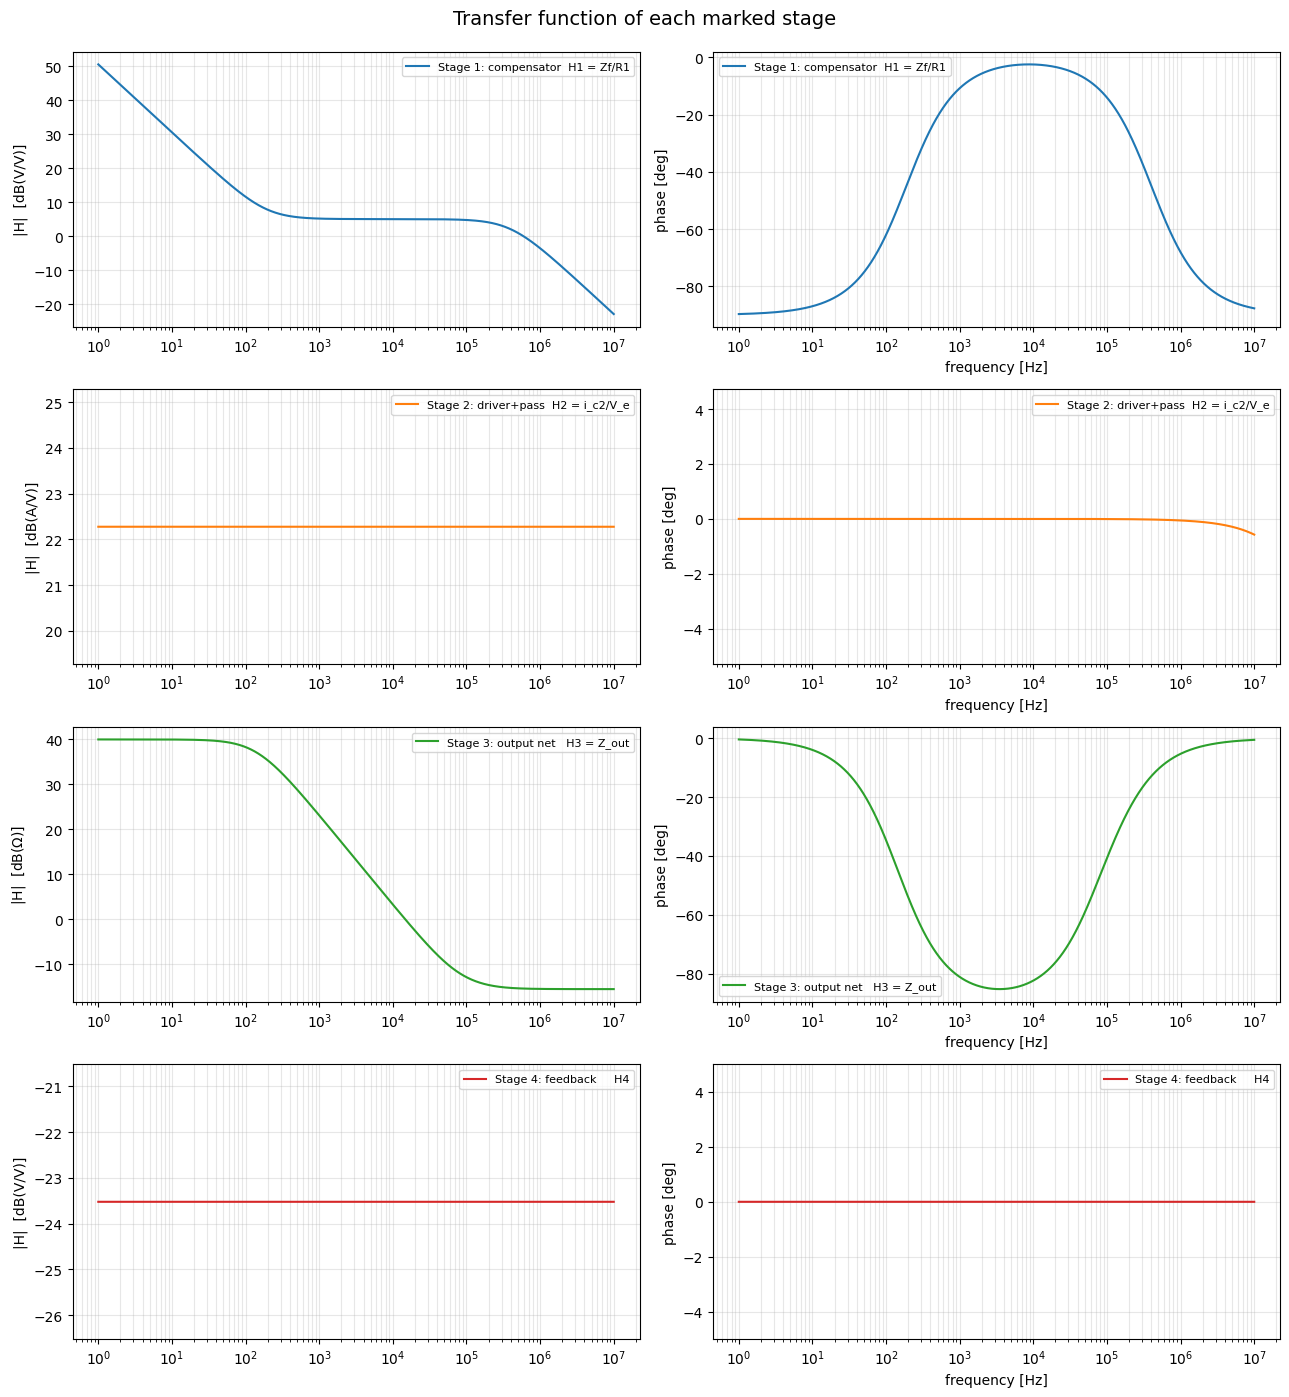

In [17]:
def _minspan(ax, data, span):
    lo, hi = np.nanmin(data), np.nanmax(data)   # widen axis so flat curves read flat
    if hi - lo < span:
        mid = 0.5*(lo+hi); ax.set_ylim(mid-span/2, mid+span/2)

def bode_pair(axm, axp, H, label, color=None, unit='dB'):
    mag = 20*np.log10(np.abs(H)); ph = np.angle(H, deg=True)
    axm.semilogx(f, mag, color=color, label=label)
    axp.semilogx(f, ph,  color=color, label=label)
    _minspan(axm, mag, 6.0); _minspan(axp, ph, 10.0)   # avoid misleading zoom
    axm.set_ylabel('|H|  ['+unit+']'); axp.set_ylabel('phase [deg]')
    for a in (axm, axp):
        a.grid(True, which='both', alpha=0.3); a.legend(loc='best', fontsize=8)
    axp.set_xlabel('frequency [Hz]')

stages = [('Stage 1: compensator  H1 = Zf/R1', H1, 'dB(V/V)', 'C0'),
          ('Stage 2: driver+pass  H2 = i_c2/V_e', H2, 'dB(A/V)', 'C1'),
          ('Stage 3: output net   H3 = Z_out', H3, r'dB($\Omega$)', 'C2'),
          ('Stage 4: feedback     H4', H4*np.ones_like(s), 'dB(V/V)', 'C3')]

fig, ax = plt.subplots(4, 2, figsize=(13, 14))
for i,(name,H,unit,col) in enumerate(stages):
    bode_pair(ax[i,0], ax[i,1], H, name, color=col, unit=unit)
fig.suptitle('Transfer function of each marked stage', fontsize=14, y=0.995)
fig.tight_layout()
plt.show()

## 7 · Loop gain $T(s)=H_1H_2H_3H_4$ — stability

$$T(s)=\frac{Z_f(s)}{R_1}\cdot\beta_2 g_{m1}\cdot Z_{out}(s)\cdot H_4$$

Gain crossover $\omega_c$: $|T|=1$ (0 dB). Phase margin $\mathrm{PM}=180^\circ+\angle T(j\omega_c)$.
Gain margin: $-|T|_{dB}$ where $\angle T=-180^\circ$.

In [18]:
T = H1 * H2 * H3 * H4              # loop gain
magT = 20*np.log10(np.abs(T))
phT  = np.angle(T, deg=True)

def log_interp(xq, x, y):
    return np.interp(np.log10(xq), np.log10(x), y)

def crossings(y, x, level):
    out = []
    d = np.sign(y - level)
    idx = np.where(np.diff(d) != 0)[0]
    for k in idx:
        # linear interp in log-f
        lf = np.interp(level, [y[k], y[k+1]], [np.log10(x[k]), np.log10(x[k+1])])
        out.append(10**lf)
    return out

# gain crossover(s) and phase margin
fc_list = crossings(magT, f, 0.0)
print('--- Loop-gain summary ---')
print('DC (1 Hz) loop gain : %6.1f dB' % magT[0])
if fc_list:
    for fc in fc_list:
        pm = 180 + log_interp(fc, f, phT)
        print('gain crossover      : %8.1f Hz   PM = %+6.1f deg' % (fc, pm))
else:
    print('no 0 dB crossing in the swept range')

# phase crossover(s) and gain margin (phase through -180)
fp_list = crossings(phT, f, -180.0)
for fpx in fp_list:
    gm_db = -log_interp(fpx, f, magT)
    print('phase crossover     : %8.1f Hz   GM = %+6.1f dB' % (fpx, gm_db))

--- Loop-gain summary ---
DC (1 Hz) loop gain :   89.3 dB
gain crossover      :  23436.6 Hz   PM = +102.2 deg


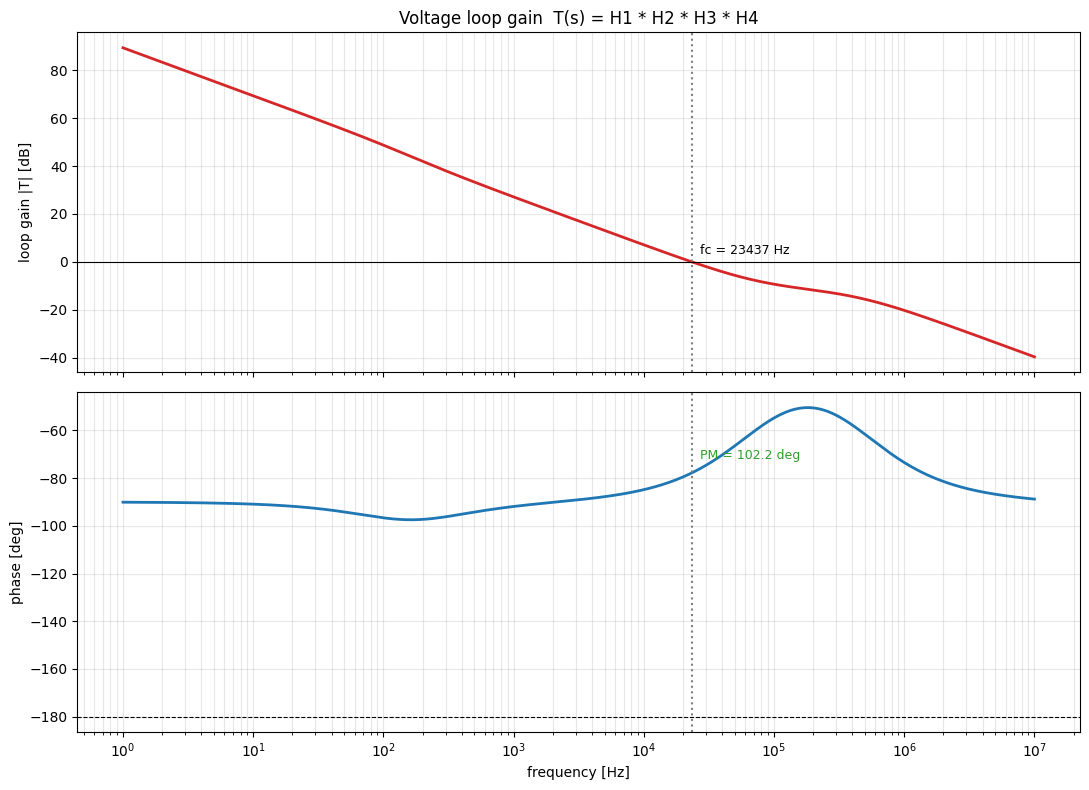

In [19]:
fig, (axm, axp) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axm.semilogx(f, magT, 'C3', lw=2, label='|T|')
axm.axhline(0, color='k', lw=0.8)
axm.set_ylabel('loop gain |T| [dB]'); axm.grid(True, which='both', alpha=0.3)
axp.semilogx(f, phT, 'C0', lw=2, label='phase T')
axp.axhline(-180, color='k', lw=0.8, ls='--')
axp.set_ylabel('phase [deg]'); axp.set_xlabel('frequency [Hz]')
axp.grid(True, which='both', alpha=0.3)

for fc in fc_list:
    pm = 180 + log_interp(fc, f, phT)
    for a in (axm, axp): a.axvline(fc, color='0.5', ls=':')
    axm.annotate('fc = %.0f Hz' % fc, (fc, 0), textcoords='offset points',
                 xytext=(6, 6), fontsize=9)
    axp.annotate('PM = %.1f deg' % pm, (fc, log_interp(fc, f, phT)),
                 textcoords='offset points', xytext=(6, 10), fontsize=9,
                 color=('C2' if pm>45 else 'C3'))
axm.set_title('Voltage loop gain  T(s) = H1 * H2 * H3 * H4')
fig.tight_layout(); plt.show()

## 7b · Compensator vs. the rest of the loop (loop shaping)

Overlay of the **compensator** $H_1$, **everything else** $H_{rest}=H_2H_3H_4$
(driver+pass × output × feedback), and their product the loop gain $T=H_1H_{rest}$.

The dotted line is the **loop crossover** — the crossing that matters: where $|T|=0$ dB,
i.e. $|H_1|=1/|H_{rest}|$. There the angles add, $\angle T=\angle H_1+\angle H_{rest}$,
and $\mathrm{PM}=180^\circ+\angle T$. The readout at that line shows how the phase budget is
spent: the integrator holds $\angle H_1\approx-90^\circ$, so the margin is set by the extra lag
$\angle H_{rest}$ that the power stage + load add.

--- angles at the loop crossover  |T| = 0 dB ---
  fc =  23436.6 Hz :  comp =   -3.8  rest =  -74.0  ->  loop =  -77.8 deg   PM = +102.2 deg


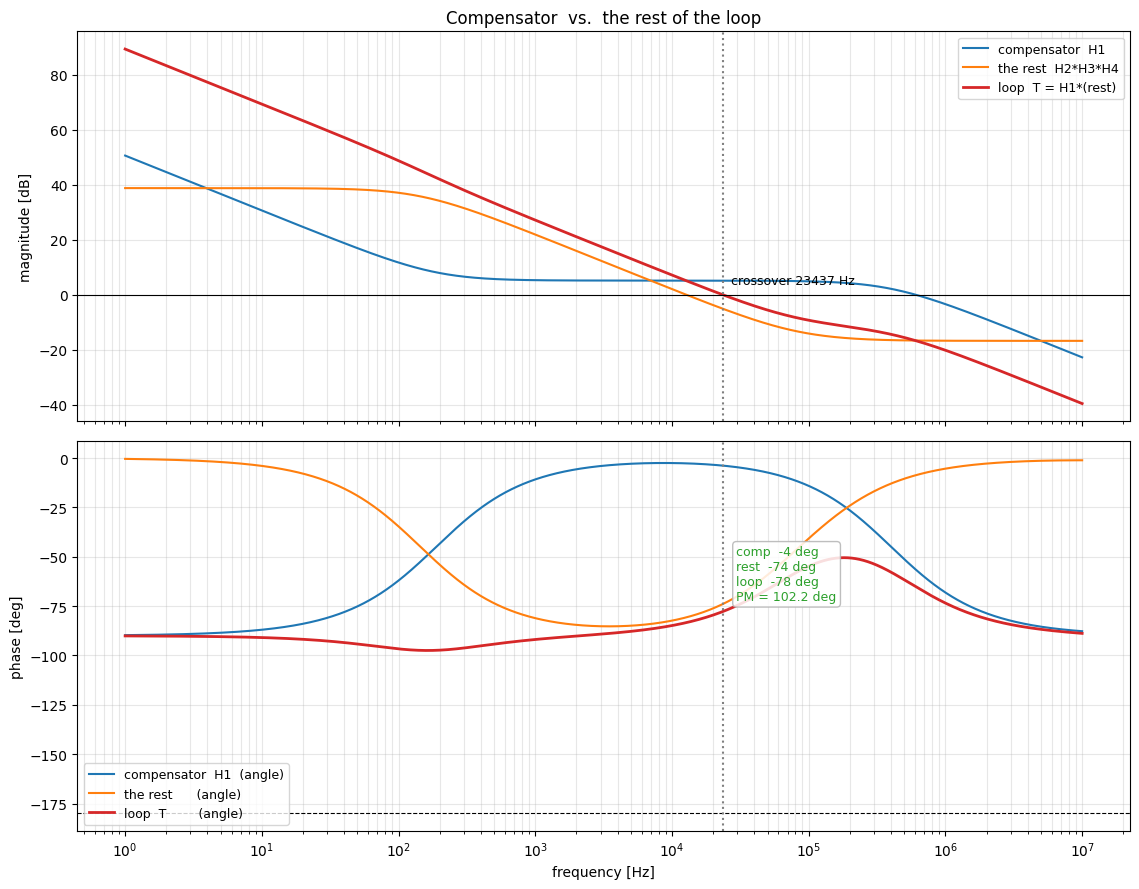

In [20]:
# ----- compensator vs. 'the rest' (H2*H3*H4) -----------------------------
H_rest = H2 * H3 * H4                       # driver+pass x output x feedback
aH1, aR, aT = (np.angle(H1, deg=True), np.angle(H_rest, deg=True), np.angle(T, deg=True))
mH1, mR, mT = (20*np.log10(np.abs(H1)), 20*np.log10(np.abs(H_rest)), 20*np.log10(np.abs(T)))
fc_cross = crossings(mT, f, 0.0)                 # loop 0 dB crossover(s)

fig, (axm, axp) = plt.subplots(2, 1, figsize=(11.5, 9), sharex=True)
axm.semilogx(f, mH1, 'C0',      label='compensator  H1')
axm.semilogx(f, mR,  'C1',      label='the rest  H2*H3*H4')
axm.semilogx(f, mT,  'C3', lw=2, label='loop  T = H1*(rest)')
axm.axhline(0, color='k', lw=0.8)
axm.set_ylabel('magnitude [dB]'); axm.grid(True, which='both', alpha=0.3)
axm.legend(loc='upper right', fontsize=9)

axp.semilogx(f, aH1, 'C0',      label='compensator  H1  (angle)')
axp.semilogx(f, aR,  'C1',      label='the rest      (angle)')
axp.semilogx(f, aT,  'C3', lw=2, label='loop  T        (angle)')
axp.axhline(-180, color='k', lw=0.8, ls='--')
axp.set_ylabel('phase [deg]'); axp.set_xlabel('frequency [Hz]')
axp.grid(True, which='both', alpha=0.3); axp.legend(loc='lower left', fontsize=9)

print('--- angles at the loop crossover  |T| = 0 dB ---')
for fc in fc_cross:
    a1 = log_interp(fc, f, aH1); ar = log_interp(fc, f, aR); at = log_interp(fc, f, aT)
    for a in (axm, axp): a.axvline(fc, color='0.5', ls=':')
    axm.annotate('crossover %.0f Hz' % fc, (fc, 0), textcoords='offset points',
                 xytext=(6, 8), fontsize=9)
    axp.annotate('comp  %+.0f deg\nrest  %+.0f deg\nloop  %+.0f deg\nPM = %.1f deg'
                 % (a1, ar, at, 180+at), (fc, at), textcoords='offset points',
                 xytext=(10, 6), fontsize=9, va='bottom',
                 color=('C2' if 180+at>45 else 'C3'),
                 bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.85))
    print('  fc = %8.1f Hz :  comp = %+6.1f  rest = %+6.1f  ->  loop = %+6.1f deg   PM = %+5.1f deg'
          % (fc, a1, ar, at, 180+at))

axm.set_title('Compensator  vs.  the rest of the loop')
fig.tight_layout(); plt.show()

## 8 · Closed-loop step response  ($V_{set}\to V_{out}$)

Closed-loop reference transfer function, assembled from the same stage blocks:

$$\frac{V_{out}}{V_{set}}=\frac{G_m Z_{out}\,(1+Z_f/R_1)}{1+T},\qquad
T=\frac{Z_f}{R_1}\,G_m Z_{out}\,H_4$$

DC value $=1/H_4=15$, so $V_{out}$ settles to $15\,V_{set}$. With the optimized
compensator the loop is well damped (PM ≈ 90° at the nominal load); the ~25–30 %
overshoot seen here is **not** ringing — it is feed-forward of the setpoint edge through
the *noise-gain* term $(1+Z_f/R_1)$ (the compensator zero appears in the reference path).
A small RC low-pass on $V_{set}$ (or a slew-limited DAC ramp) removes it; load
transients do not see this zero.

*Numerics:* the closed-loop polynomial coefficients span ~20 decades, which destroys naive
root-finding / companion-matrix methods. We **frequency-scale** ($s=\omega_0 x$) so the
coefficients are $O(1)$, then take a state-space step (scipy, with a pure-numpy fallback).
The small instantaneous jump at $t=0$ is real — a $V_{set}$ edge feeds through the cap ESRs.
Edit `Vstep` for the step size; the optional pass pole `fp_pass` is omitted here (negligible at ms).

DC gain V_out/V_set = 15.000   (final = 15.000 V for a 1.000 V step)
dominant zeta = 1.000   overshoot = 53 %   t_peak = 47.3 us   2% settling = 2818 us


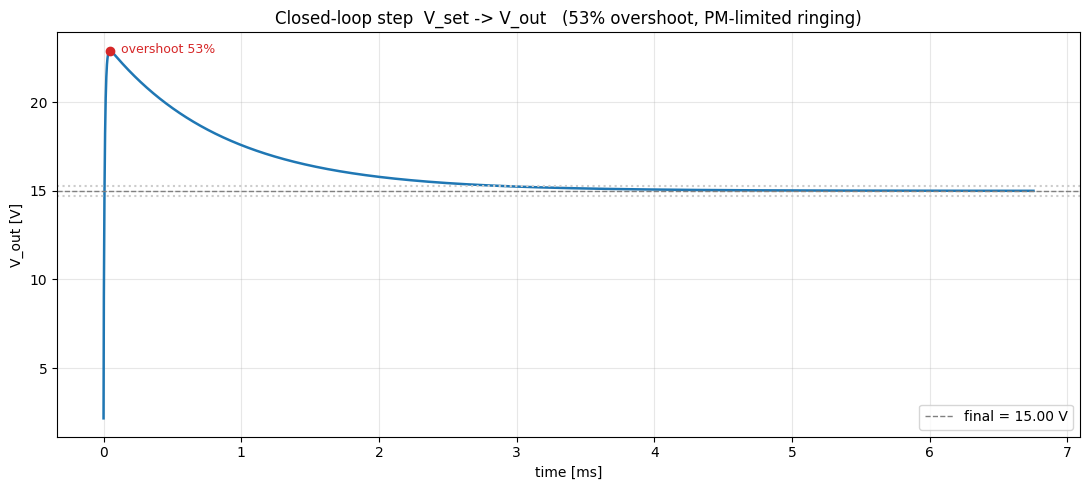

In [21]:
# ---- closed loop V_out/V_set = Gm*Zout*(1+Zf/R1) / (1+T)  as polynomials in s ----
def pmul(a,b): return np.polymul(a,b)
def padd(a,b): return np.polyadd(a,b)
def par(n1,d1,n2,d2):                      # parallel of two impedances -> (num,den)
    return pmul(n1,n2), padd(pmul(n1,d2), pmul(n2,d1))

nb_=[R2*C1,1.0]; db_=[C1,0.0]              # Zf branch: R2 + 1/(sC1)
if C3>0: nZf,dZf = par(nb_,db_,[1.0],[C3,0.0])
else:    nZf,dZf = nb_,db_
nA, dA = nZf, pmul(dZf,[R1])               # A = Zf/R1

n_cap=[R5*C2,1.0]; d_cap=[C2,0.0]                       # C2 + ESR R5
n_ce =[R_esrL*C_load,1.0]; d_ce=[C_load,0.0]            # load cap + ESR
n_load,d_load = par([R_load],[1.0], n_ce,d_ce)          # Rload || (...)
n_Zo,d_Zo     = par(n_cap,d_cap, n_load,d_load)         # Zout

nP,dP = pmul([Gm_dc], n_Zo), d_Zo          # forward P = Gm*Zout (fp_pass omitted)
num_cl = pmul(nP, padd(dA, nA))            # Gm*Zout*(1+Zf/R1)
den_cl = padd(pmul(dA,dP), pmul([H4], pmul(nA,nP)))     # 1 + T
dc_gain = np.polyval(num_cl,0.0)/np.polyval(den_cl,0.0) # = 1/H4

# ---- robust step: frequency-scale s=w0*x so coeffs are O(1) ----
Vstep = 1.0                                # V_set step amplitude [V]  (edit me)
ndeg  = len(den_cl)-1
w0    = abs(den_cl[-1]/den_cl[0])**(1.0/ndeg)           # geo-mean |pole|, no roots
scale = lambda c: np.asarray(c,float)*(w0**np.arange(len(c)-1,-1,-1))
nS, dS = scale(num_cl), scale(den_cl)

psc   = np.roots(dS)*w0                     # accurate poles (well-scaled)
tmax  = 8.0/np.min(np.abs(psc.real))       # cover slowest decay
t     = np.linspace(0.0, tmax, 6000)
try:
    from scipy import signal
    _, yn = signal.step(signal.StateSpace(*signal.tf2ss(nS, dS)), T=w0*t)
except Exception:                          # pure-numpy partial-fraction fallback
    ps=np.roots(dS); dd=np.polyder(dS); Ts=w0*t
    yn=np.full(Ts.shape, np.polyval(nS,0)/np.polyval(dS,0), dtype=complex)
    for p in ps: yn = yn + np.polyval(nS,p)/(p*np.polyval(dd,p))*np.exp(p*Ts)
    yn = yn.real

Vout = Vstep*yn; yf = Vstep*dc_gain
peak = Vout.max(); tp = t[np.argmax(Vout)]
overshoot = 100*(peak-yf)/yf
outside   = np.where(np.abs(Vout-yf) > 0.02*abs(yf))[0]
tset      = t[outside[-1]] if len(outside) else 0.0
zeta = -psc.real/np.abs(psc)
print('DC gain V_out/V_set = %.3f   (final = %.3f V for a %.3f V step)' % (dc_gain, yf, Vstep))
print('dominant zeta = %.3f   overshoot = %.0f %%   t_peak = %.1f us   2%% settling = %.0f us'
      % (zeta[np.argmin(np.abs(psc.real))], overshoot, tp*1e6, tset*1e6))

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(t*1e3, Vout, 'C0', lw=1.8)
ax.axhline(yf, color='0.5', ls='--', lw=1, label='final = %.2f V' % yf)
ax.axhline(1.02*yf, color='0.8', ls=':'); ax.axhline(0.98*yf, color='0.8', ls=':')
ax.plot(tp*1e3, peak, 'C3o')
ax.annotate('overshoot %.0f%%' % overshoot, (tp*1e3, peak),
            textcoords='offset points', xytext=(8,-2), color='C3', fontsize=9)
ax.set_xlabel('time [ms]'); ax.set_ylabel('V_out [V]')
ax.set_title('Closed-loop step  V_set -> V_out   (%.0f%% overshoot, PM-limited ringing)' % overshoot)
ax.grid(alpha=0.3); ax.legend(loc='lower right')
fig.tight_layout(); plt.show()

## 9 · Notes, assumptions & history

**Modelling assumptions** (all exposed as variables so you can refine them):
- $Q2$ modelled as an ideal current gain $\beta_2$ into a high-impedance collector (no $f_T$/Miller — use `fp_pass`).
- $D1$ + $R_3$ are bias only; small-signal they vanish for `rd_D1 = 0`.
- $Q1$ transconductance $g_{m1}=1/(R_4+r_{e1})$ with `re1 = 0` (ideal); set `re1 = 0.026/Ic1` for a real bias point.
- Op-amp GBW not modelled. **Caution:** a power-Darlington's $\beta$ corner sits at
  $f_T/\beta_0$ (a few kHz for a TIP125-class part!) — section 10 therefore re-checks every
  design with `fp_pass` = 50 kHz and even 20 kHz before trusting it.
- Load $R_6=R_{load}\parallel(R_{esrL}+1/sC_{load})$.

**History:**
- *Schematic first guess* (`R2=10k, C1=1n, C3=0`): fine at the nominal resistive load
  (PM ≈ 44° @ 11 kHz) but **PM ≈ 20° with a 10 Ω + 100 µF load** and sensitivity peak ≈ 3 —
  rings badly for capacitive loads.
- *Optimized values* (`R2=33k, C1=10n, C3=47p`, section 10): zero moved down to ≈480 Hz so
  big-cap loads cross over with the zero already active, mid-band gain 3.3 sets the resistive
  crossover ≈ 20 kHz, and the 47 p pole (≈100 kHz) rolls off HF. Worst realistic load ≥ 56° PM;
  even 1000 µF/20 mΩ stays stable (≈ 43°).

## 10 · Load sweep — robustness across load types ($R_6$)

$R_6$ is *"the impedance of the connected load"*, so the compensator must be stable for
**anything the user plugs in**, not just the nominal 100 Ω ∥ 1 µF. The sweep below covers
resistive loads from no-load to heavy, MLCC / electrolytic / polymer capacitive loads and a
low-ESR 1000 µF worst case. For each load it reports:

- $f_c$, PM, GM — crossover, phase and gain margin of $T$,
- $S_{pk}=\max|1/(1+T)|$ — **sensitivity peak**, a single robustness number
  ($S_{pk}<1.5$ ⇔ well damped, $>2$ ⇔ ringing; it also bounds the closed-loop
  resonance seen by load transients),
- the same margins with a **pessimistic extra pole** `f_sens = 50 kHz` standing in for
  everything the model ignores (op-amp GBW, Darlington $f_T/\beta$, layout).

**How the optimization was done (grid search over E12 values, R1 fixed 10 k):** require a
single 0 dB crossing, nominal PM ≥ 60°, crossover ≤ ~20 kHz (model validity), and with the
50 kHz sensitivity pole still PM ≥ 45° / GM ≥ 10 dB — then maximise the *worst-case*
crossover. Winner: $R_2=33\,$k, $C_1=10\,$n, $C_3=47\,$p
($f_z\approx480$ Hz, $f_p\approx103$ kHz, mid-band gain 3.3).

Rule-of-thumb behind the numbers: the **mid-band gain $R_2/R_1$ sets the resistive-load
crossover** (on the $-1/\omega C_2$ slope), while the **zero $f_z$ must sit below the
crossover of the biggest expected load cap** — big caps drag $f_c$ down, and if $f_c$ lands
below $f_z$ the loop is back to a double-slope (−90° integrator on top of the −90° cap pole).

load case                  fc [Hz]   PM [deg]  GM [dB]   Spk  |  with 50 kHz pole: PM, Spk
-----------------------------------------------------------------------------------------------
no load (100k)               26049     104.0     inf   1.00  |    77.5, 1.08
R 1k (light)                 26044     104.0     inf   1.00  |    77.6, 1.08
R 100R (nominal)             25991     104.3     inf   1.00  |    77.9, 1.08
R 10R (heavy)                25436     107.2     inf   1.00  |    81.6, 1.07
100R + 1uF/1R (orig)         23379     102.2     inf   1.00  |    78.0, 1.08
1k + 4u7/5m MLCC             17207      95.3     inf   1.03  |    76.9, 1.13
10k + 10uF/10m idle          12509      92.0     inf   1.01  |    78.3, 1.12
10R + 100uF/50m               2254      92.4     inf   1.00  |    89.8, 1.01
10R + 330uF/30m poly           749      82.0     inf   1.00  |    81.1, 1.00
100R + 470uF/0.5R elyt         838     127.1     inf   1.00  |   126.1, 1.03
10R + 1000uF/20m (!)           292      62.

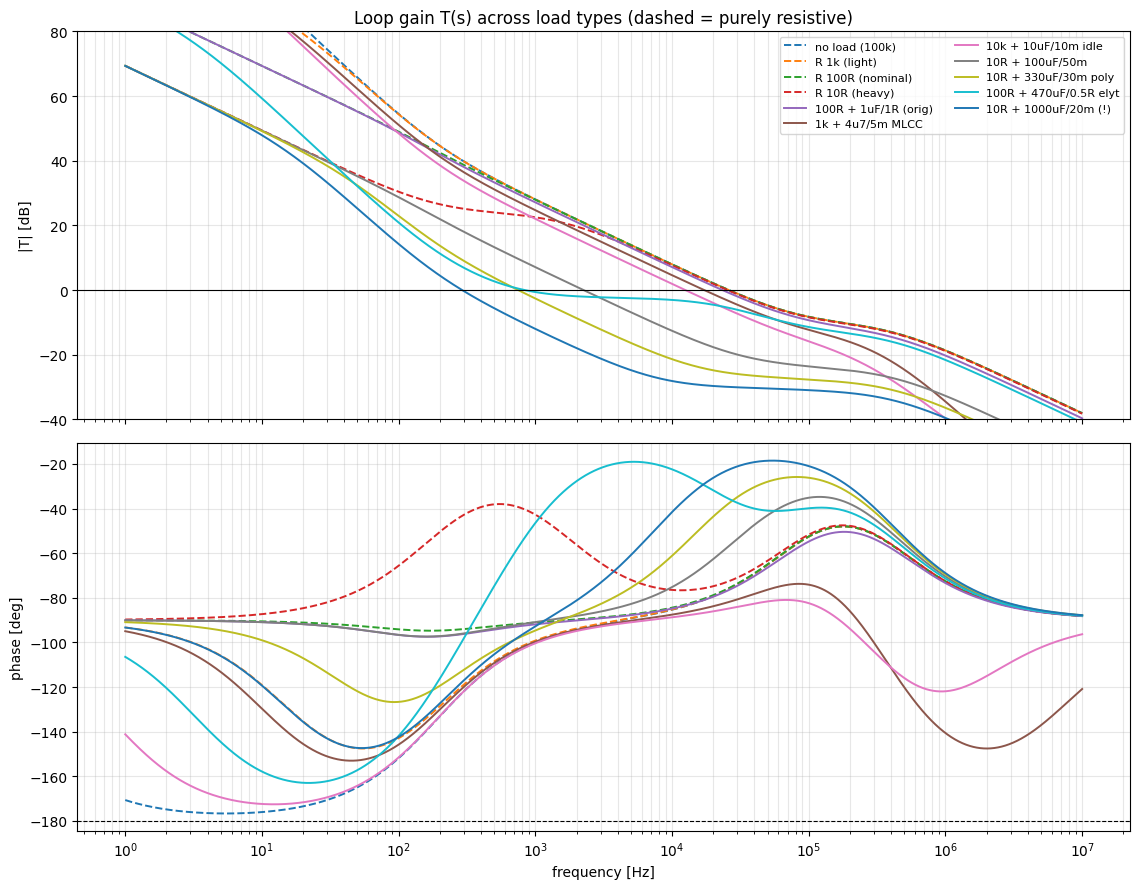

In [22]:
# ---- load sweep: loop margins for many load types (uses R1,R2,C1,C3,... from above) ----
f_sens = 50e3        # pessimistic unmodeled pole for the robustness column [Hz]

load_cases = {      # name: (R_load, C_load, R_esrL)
    'no load (100k)'         : (1e5,   0.0,     0.0),
    'R 1k (light)'           : (1e3,   0.0,     0.0),
    'R 100R (nominal)'       : (100.0, 0.0,     0.0),
    'R 10R (heavy)'          : (10.0,  0.0,     0.0),
    '100R + 1uF/1R (orig)'   : (100.0, 1e-6,    1.0),
    '1k + 4u7/5m MLCC'       : (1e3,   4.7e-6,  0.005),
    '10k + 10uF/10m idle'    : (1e4,   10e-6,   0.01),
    '10R + 100uF/50m'        : (10.0,  100e-6,  0.05),
    '10R + 330uF/30m poly'   : (10.0,  330e-6,  0.03),
    '100R + 470uF/0.5R elyt' : (100.0, 470e-6,  0.5),
    '10R + 1000uF/20m (!)'   : (10.0,  1000e-6, 0.02),
}

def T_of_load(Rl, Cl, El, fp=None):
    Y = 1.0/Rl
    if Cl > 0:
        Y = Y + 1.0/(El + 1.0/(s*Cl))
    Zo   = 1.0/(1.0/(R5 + 1.0/(s*C2)) + Y)
    H2l  = Gm_dc/(1.0 + s/(2*np.pi*fp)) if fp else Gm_dc*np.ones_like(s)
    return H1 * H2l * Zo * H4          # H1, Gm_dc, H4 from the stage cells

def margins(T):
    m = 20*np.log10(np.abs(T)); p = np.unwrap(np.angle(T))*180/np.pi
    idx = np.where(np.diff(np.sign(m)) != 0)[0]
    if len(idx) == 0: return np.nan, np.nan, np.inf, np.max(np.abs(1/(1+T)))
    pms, fcs = [], []
    for k in idx:
        lf = np.interp(0.0, [m[k+1], m[k]], [np.log10(f[k+1]), np.log10(f[k])])
        fcs.append(10**lf); pms.append(180.0 + np.interp(lf, np.log10(f), p))
    gm = np.inf
    for k in np.where(np.diff(np.sign(p + 180.0)) != 0)[0]:
        lf = np.interp(-180.0, [p[k], p[k+1]], [np.log10(f[k]), np.log10(f[k+1])])
        gm = min(gm, -np.interp(lf, np.log10(f), m))
    j = int(np.argmin(pms))
    return fcs[j], min(pms), gm, np.max(np.abs(1.0/(1.0+T)))

print('load case                  fc [Hz]   PM [deg]  GM [dB]   Spk  |  with %d kHz pole: PM, Spk' % (f_sens/1e3))
print('-'*95)
fig, (axm, axp) = plt.subplots(2, 1, figsize=(11.5, 9), sharex=True)
for name, (Rl, Cl, El) in load_cases.items():
    T_l = T_of_load(Rl, Cl, El)
    fc, pm, gm, spk = margins(T_l)
    _, pm2, _, spk2 = margins(T_of_load(Rl, Cl, El, fp=f_sens))
    gmtxt = ('%5.1f' % gm) if np.isfinite(gm) else '  inf'
    warn = '  <-- watch' if min(pm, pm2) < 45 or max(spk, spk2) > 1.6 else ''
    print('%-25s %8.0f   %7.1f   %s   %4.2f  |  %6.1f, %4.2f%s'
          % (name, fc, pm, gmtxt, spk, pm2, spk2, warn))
    ls = '-' if Cl > 0 else '--'
    axm.semilogx(f, 20*np.log10(np.abs(T_l)), ls, lw=1.4, label=name)
    axp.semilogx(f, np.unwrap(np.angle(T_l))*180/np.pi, ls, lw=1.4, label=name)
axm.axhline(0, color='k', lw=0.8); axm.set_ylabel('|T| [dB]'); axm.set_ylim(-40, 80)
axp.axhline(-180, color='k', lw=0.8, ls='--'); axp.set_ylabel('phase [deg]')
axp.set_xlabel('frequency [Hz]')
for a in (axm, axp): a.grid(True, which='both', alpha=0.3)
axm.legend(fontsize=8, ncol=2); axm.set_title('Loop gain T(s) across load types (dashed = purely resistive)')
fig.tight_layout(); plt.show()